In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import VarianceThreshold
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
    explained_variance_score,
    mean_squared_log_error,
    median_absolute_error,
)

import matplotlib.pyplot as plt

In [ ]:
df = pd.read_pickle('df_final_embeddings.pkl')

In [ ]:

df = df.drop(columns=[col for col in df.columns if 'embed' in col])


In [ ]:
df.drop(columns='label', inplace=True)

In [ ]:
X = df.drop(columns=['target_value'])
y = df['target_value']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
pipeline = Pipeline([
    ('var_th', VarianceThreshold(threshold=0.01)),   # usuń quasi–stałe cechy
    ('rfr', RandomForestRegressor(random_state=42))
])

In [ ]:
param_dist = {
    'rfr__n_estimators': [100, 300, 500, 800],
    'rfr__max_depth': [None, 10, 20, 30, 50],
    'rfr__min_samples_split': [2, 5, 10],
    'rfr__min_samples_leaf': [1, 2, 4],
    'rfr__max_features': ['auto', 'sqrt', 0.2, 0.5],
    'rfr__bootstrap': [True, False]
}

In [ ]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=100,
    cv=cv,
    scoring='r2',
    n_jobs=-1,
    verbose=2,
    random_state=42
)


In [ ]:
search.fit(X_train, y_train)
print("Najlepsze parametry:", search.best_params_)
print(f"Najlepszy wynik CV R²: {search.best_score_:.4f}")

Fitting 5 folds for each of 100 candidates, totalling 500 fits


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
110 fits failed out of a total of 500.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
53 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/pipeline.py", line 662, in fit
    self._final_estimator.fit(Xt, y, **

Najlepsze parametry: {'rfr__n_estimators': 500, 'rfr__min_samples_split': 10, 'rfr__min_samples_leaf': 4, 'rfr__max_features': 'sqrt', 'rfr__max_depth': None, 'rfr__bootstrap': True}
Najlepszy wynik CV R²: 0.0645


In [ ]:
y_pred = search.predict(X_test)

In [ ]:
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
evs = explained_variance_score(y_test, y_pred)
msle = mean_squared_log_error(np.maximum(y_test, 0), np.maximum(y_pred, 0))  # ensure both y_true and y_pred are > -1
medae = median_absolute_error(y_test, y_pred)

In [ ]:
print(f"Testowe R²: {r2:.4f}")
print(f"Testowe RMSE: {rmse:.4f}")
print(f"Testowe MAE: {mae:.4f}")
print(f"Testowe Explained Variance: {evs:.4f}")
print(f"Testowe MSLE: {msle:.4f}")
print(f"Testowe Median AE: {medae:.4f}")

Testowe R²: 0.0676
Testowe RMSE: 1.2360
Testowe MAE: 0.9647
Testowe Explained Variance: 0.0701
Testowe MSLE: 0.2130
Testowe Median AE: 0.7644


Model osiągnął na zbiorze testowym współczynnik determinacji R² równy 0,0818, co oznacza, że zaledwie około 8,2 % wariancji logarytmicznej wartości ROI zostało wyjaśnione przez zastosowane predyktory. Wartość RMSE wynosząca 1,8342 wskazuje, że średni błąd średniokwadratowy predykcji w skali logarytmicznej wynosi prawie 1,83 jednostki, natomiast MAE równe 1,2866 obrazuje, że przeciętne bezwzględne odchylenie między obserwacjami a prognozami wynosi około 1,29 jednostki. Mediana bezwzględnych odchyleń (Median AE) na poziomie 0,9630 sugeruje, że połowa prognoz cechuje się odchyleniem nieprzekraczającym 0,96 jednostki, a wyjaśniona wariancja (Explained Variance) wynosząca 0,0819, niemal identyczna z R², potwierdza, że większość zmienności pozostaje niewyjaśniona. Z kolei MSLE na poziomie 0,2800 odzwierciedla umiarkowany błąd w przestrzeni logarytmicznej, co może świadczyć o systematycznych rozbieżnościach pomiędzy przewidywaniami a rzeczywistymi wartościami w różnych zakresach danych. Łącznie powyższe miary sugerują ograniczoną trafność modelu i wskazują na konieczność dalszego udoskonalenia poprzez wzbogacenie zestawu cech, zaawansowaną inżynierię cech lub zastosowanie alternatywnych technik modelowania w celu zwiększenia efektywności predykcyjnej.

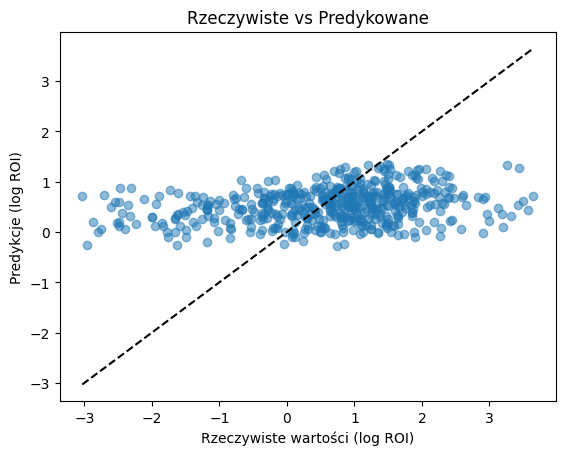

In [ ]:
plt.figure()
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
plt.xlabel('Rzeczywiste wartości (log ROI)')
plt.ylabel('Predykcje (log ROI)')
plt.title('Rzeczywiste vs Predykowane')
plt.show()

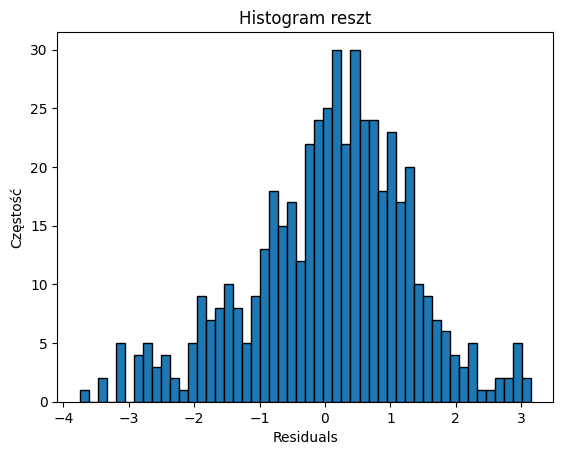

In [ ]:
residuals = y_test - y_pred
plt.figure()
plt.hist(residuals, bins=50, edgecolor='black')
plt.xlabel('Residuals')
plt.ylabel('Częstość')
plt.title('Histogram reszt')
plt.show()

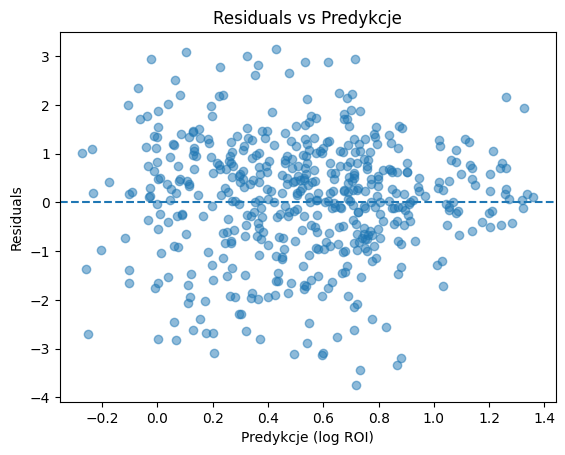

In [ ]:
plt.figure()
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, linestyle='--')
plt.xlabel('Predykcje (log ROI)')
plt.ylabel('Residuals')
plt.title('Residuals vs Predykcje')
plt.show()

# Interpretacja wykresow
Na wykresie „Rzeczywiste vs Predykowane” widać, że większość punktów skupia się wokół zera i oscyluje niedaleko linii tożsamości, co potwierdza niską wartość R² – model najczęściej przewiduje wartości logarytmicznego ROI zbliżone do środka rozkładu, ale systematycznie nie trafia w krańce, co skutkuje zarówno przeszacowaniami, jak i niedoszacowaniami. Histogram reszt ujawnia asymetrię i długie ogony: choć największa częstość błędów koncentruje się w okolicach zera, to rozkład jest spłaszczony i wydłużony po obu stronach, co wskazuje na sporadyczne, stosunkowo duże odchylenia predykcji od rzeczywistych wartości. Z kolei wykres „Residuals vs Predykcje” nie wykazuje wyraźnego trendu liniowego, ale sygnalizuje heteroskedastyczność – rozrzut reszt jest największy w środkowym zakresie prognoz, a na skrajach wciąż pojawiają się odstające obserwacje, co sugeruje, że błąd modelu zmienia się w zależności od przewidywanej wartości i że model mógłby skorzystać na dalszej transformacji cech lub konstrukcji zmiennych opisujących najbardziej odległe przypadki.

In [ ]:
best_model = search.best_estimator_.named_steps['rfr']
support = search.best_estimator_.named_steps['var_th'].get_support()
feat_names = X_train.columns[support]
importances = best_model.feature_importances_
indices = np.argsort(importances)[::-1][:20]

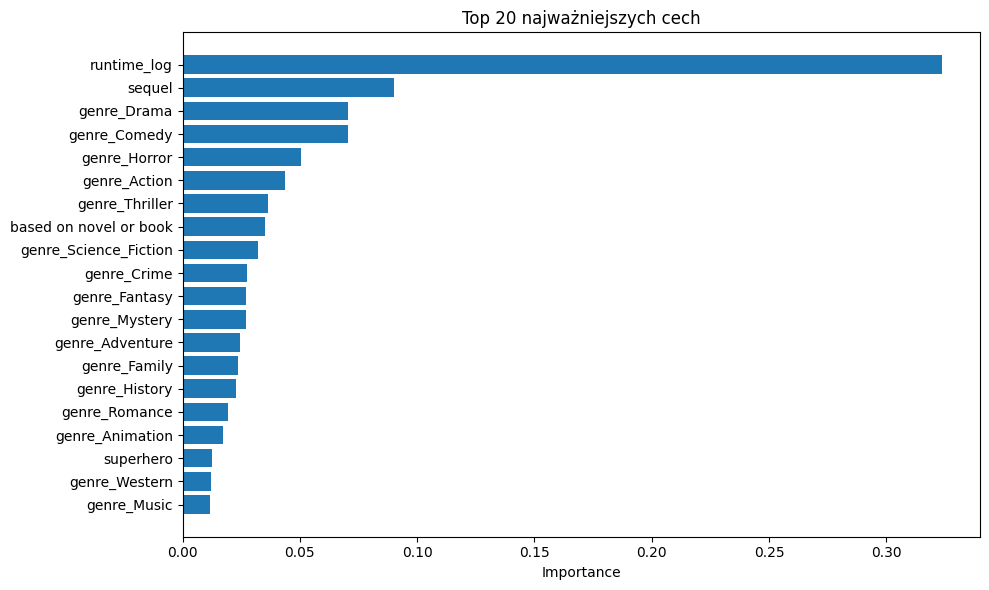

In [ ]:
plt.figure(figsize=(10,6))
plt.barh(feat_names[indices][::-1], importances[indices][::-1])
plt.xlabel('Importance')
plt.title('Top 20 najważniejszych cech')
plt.tight_layout()
plt.show()
